In [ ]:
import pandas as pd
import numpy as np

from collections import Counter # count elements' appearences in list # might not need it later

from bertagent import BERTAgent # get agency scores
import torch
import spacy
from keybert import KeyBERT     # get keywords of abstract that don't have them already
from tqdm import tqdm           # shows progress of for loops
import pickle                   # to save data even after closing the notebook

In [ ]:
## Install a package in the current venv
# !pip install --quiet bertagent
# !pip install --quiet hf_xet
# !pip install --quiet keybert


In [ ]:
# cpu or gpu
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


## Load data

In [ ]:
# load the datasets
female_df = pd.read_csv("female_only_it.csv")
male_df = pd.read_csv("male_only_it.csv")


In [ ]:
female_df.head()

,Unnamed: 0,eid,num_authors,journal_id,num_female_authors,percentage_female_author,num_weird_authors,percentage_weird_author,weird_author_present,year,keywords,abstract,citescore_20_23,percentage_cited_20_23,SNIP_20_23,SJR_20_23
0,0,85143133566,1,0,1.0,100.0,0.0,0.0,0,2023,-99,-99,3.8,74.0,1.484,0.661
1,1,85148043732,1,0,1.0,100.0,1.0,100.0,1,2023,-99,-99,3.8,74.0,1.484,0.661
2,2,85090499745,4,0,4.0,100.0,4.0,100.0,1,2021,-99,Alternating direction methods of multipliers (...,3.8,74.0,1.484,0.661
3,3,85086108454,3,0,3.0,100.0,3.0,100.0,1,2021,Complexity analysis | Contracts | Dynamic lot-...,We consider the coordination of planning decis...,3.8,74.0,1.484,0.661
4,4,85175639769,1,1,1.0,100.0,1.0,100.0,1,2023,NaN,NaN,3.8,71.0,0.281,0.216


## First view of keywords

This part is not really needed, but I'll leave it here just in case, it just gives an overview of the keywords already in the dataset

In [ ]:
# This
def clean_keywords(df):
    # remove "-99" and null values, while also splitting the keywords in the same list
    keywords_full = df["keywords"][df["keywords"] != "-99"].str.lower().str.split("|").dropna()

    # print("\nList of lists of keywords:\n",keywords_full.head())

    # get a single list with all the keywords
    cleaned_keywords = []
    for keyword_list in keywords_full:
        for keyword in keyword_list:
            cleaned_keywords.append(keyword.strip())
    return cleaned_keywords


f_keywords = clean_keywords(female_df)
m_keywords = clean_keywords(male_df)

print("\nList of female keywords:\n", f_keywords[0:7])
print("Number of female keywords: ", len(f_keywords))

print("\nList of male keywords:\n", m_keywords[0:7])
print("Number of male keywords: ", len(m_keywords))


List of female keywords:
 ['complexity analysis', 'contracts', 'dynamic lot-sizing', 'screening game', 'supply chain management', 'deep learning', 'music evaluation methods']
Number of female keywords:  215668

List of male keywords:
 ['cruise itinerary optimization', 'cruise shipping', 'itinerary cost and attractiveness', 'mixed integer linear programming', 'multiobjective optimization', 'benchmark instances', 'branch and cut']
Number of male keywords:  1584559


In [ ]:
f_kw_dict = Counter(f_keywords)
m_kw_dict = Counter(m_keywords)


In [ ]:
print("Female only papers, total of different keywords:", len(f_kw_dict))
print("Female only papers, total of different keywords:", len(m_kw_dict))

print(f_kw_dict["machine learning"])
# these will be less than the ones used later since there are abstract without keywords, so we'll get the keywords of those abstracts

Female only papers, total of different keywords: 110598
Female only papers, total of different keywords: 569605
1338


In [ ]:
f_kw_dict # quick view of the keywords

Counter({'complexity analysis': 3,
         'contracts': 5,
         'dynamic lot-sizing': 1,
         'screening game': 1,
         'supply chain management': 65,
         'deep learning': 1311,
         'music evaluation methods': 1,
         'symbolic music generation': 1,
         'symbolic music representations': 1,
         'task-oriented survey': 1,
         'diophantine equations': 2,
         'hfe polynomials': 1,
         'mq problem': 1,
         'multivariate polynomials': 1,
         'post-quantum cryptography': 10,
         'affect': 39,
         'componential process ontology': 1,
         'dimensional emotion ontology': 1,
         'discrete emotion ontology': 1,
         'emotion': 59,
         'framework of emotion ontologies': 1,
         'ontology': 132,
         'sentiment analysis': 235,
         'fevr': 1,
         'framework for evaluating recommender systems': 1,
         'survey': 72,
         'dynamic fuzzy logic': 1,
         'dynamic fuzzy machine learning'

## Assign Agency to keywords

In [ ]:
# strat BERTAgent
agent_model = BERTAgent(device = device)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: EnchantedStardust/bertagent-best
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
nlp = spacy.load("en_core_web_sm")

# to split the abstract into a list of its sentences (better for BERTAgent)
def split_sentences(abstract):
    sentences_list = []
    nlp_abstract = nlp(abstract)
    for sent in nlp_abstract.sents:
        sentences_list.append(sent.text.strip())
    return sentences_list




Splits the abstract into a list of its sentences, BERTAgent works better with single sentences.

In [ ]:
# example
split_sentences(female_df["abstract"][26])

['To go from calculus of scalar functions of one variable to multivariate calculus of vector-valued functions is a steep learning curve for many students.',
 'It takes a lot of practice to get used to the new concepts such as the directional derivatives, the di.erentiability, the many types of first order di.erential operators, parameterization of surfaces and the fundamental theorems of integrals, e.g. the Divergence Theorem and the Stokes Theorem.',
 'Along the learning process of mastering the skills, the students often need to check whether the intermediate steps in the tedious calculations are correct.',
 'Unfortunately, this is beyond the capability of an ordinary calculator and the answers provided at the end of the books.',
 "This is where computer algebra software, such as Mathematica, can come to students' help.",
 'With the developed symbolic computation tools, the students can tweak a given problem, solve a new one by hand and then check the answer against the result obtain

In [ ]:

# Gets the Agency score for every keyword in a single abstract
# How agentically a keyword is framed in the contexts where it appears
def keyword_agency_scores(abstract, keywords):
    sentences = split_sentences(abstract)           # split abstract into sentences
    sent_scores = agent_model.predict(sentences)    # gives an agency scores to each sentence

    keyword_scores = {}

    for kw in keywords:                             # loop for every keyword I want to score
        matched_scores = []

        for i in range(len(sentences)):             # Loop over every sentence of the abstract

            sentence = sentences[i]
            score = sent_scores[i]


            if kw.lower() in sentence.lower():      # Check if keyword appears in sentence
                matched_scores.append(score)        # if so, adds the score of the sentence the keyword appears in to the list


        if len(matched_scores) > 0:                 # If keyword appeared in at least one sentence
            # If a keyword appears in 2 or more sentences of the same abstract,
            # it calculates the agency of that keyword in both sentences and then it does the mean
            mean_agency = float(np.mean(matched_scores))
            max_agency = float(np.max(matched_scores))   # The max agency a keyword got in the abstract
            num_sentences = len(matched_scores)

            keyword_scores[kw] = {
                "mean_agency": mean_agency,
                "max_agency": max_agency,
                "num_sentences": num_sentences
            }
        else:
            keyword_scores[kw] = {
                "mean_agency": None,
                "max_agency": None,
                "num_sentences": 0
            }

    return keyword_scores


In [ ]:
# model for getting the keywords of papers with abstract but no keywords
kw_model = KeyBERT(model='all-MiniLM-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# function to get the keywords of an abstract
def get_keywords(text, top_n=10):
    kws = []

    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=top_n
    )

    for kw, score in keywords:
        kws.append(kw)
    return kws



In [ ]:
# iter for each row of the df and assigns an agency score to each keyword of each paper
def process_dataframe(df):
    results = []

    for _, row in tqdm(df.iterrows(), "Rows processed", leave=False):                                # for each row of the dataframe
        abstract = row["abstract"]                              # abstract of the row

        if abstract != abstract     or  abstract == "-99":      # abstracts fields can be "-99" or NaN -> can't get their keywords
            continue                                            # NaN can be found because it's always False that NaN == NaN, even if it's the same NaN

        if (row["keywords"] == row["keywords"])     and     (row["keywords"] != "-99"): # keywords fields can be "-99" or NaN
            keywords = []
            keywords_raw = row["keywords"].lower().split("|")   # cleans the keywords of the row, but they still have a space before or after or both (ex. " ciao ")
            for kw in keywords_raw:
                keywords.append(kw.strip())                     # removes the unnecessary spaces

        else:
            keywords = get_keywords(abstract)                   # if we have an abstract but not the keywords, we get them



        kw_scores = keyword_agency_scores(abstract, keywords)   # scores of the keywords

        for kw, scores in kw_scores.items():
            results.append({
                "eid": row["eid"],
                "year": row["year"],
                "journal_id": row["journal_id"],
                "keyword": kw,
                "mean_agency": scores["mean_agency"],
                "max_agency": scores["max_agency"],
                "num_sentences": scores["num_sentences"]
            })

    return results


In [ ]:
# female_df takes about 1h with gpu, male_df about 7h, but we just need to do them once... hopefully :)

# female_kw_df_full = pd.DataFrame( process_dataframe(female_df) ) # 50026 rows total
# female_kw_df_full.to_csv('female_kw_df_full.csv', index=False) # used to save the df to csv


In [ ]:
# male_kw_df_full = pd.DataFrame( process_dataframe(male_df) ) # 372055 rows total
# male_kw_df_full.to_csv('male_kw_df_full.csv', index=False)

## Load the created dataset

This dataset has every keyword of every abstract and its agency score (plus other identification fields like eid of the paper).  
Which means that there are multiple occurrences of the same keyword if different abstracts had the same keyword.  
After this It will be aggregated by doing the mean of each keyword.  

In [ ]:
# read the agency datasets we created earlier
female_kw_df_full = pd.read_csv("female_kw_df_full.csv")
male_kw_df_full = pd.read_csv("male_kw_df_full.csv")

female_kw_df_full # dataset with the agency of all the keywords of all abstracts

,eid,year,journal_id,keyword,mean_agency,max_agency,num_sentences
0,85090499745,2021,0,semidefinite programs,0.055280,0.139279,2
1,85090499745,2021,0,dual feasible,0.200551,0.200551,1
2,85090499745,2021,0,dnn semidefinite,NaN,NaN,0
3,85090499745,2021,0,primal optimal,-0.212406,-0.212406,1
4,85090499745,2021,0,dual objective,0.200551,0.200551,1
...,...,...,...,...,...,...,...
241384,85090508698,2020,2164,attributed unhealthy,NaN,NaN,0
241385,85090508698,2020,2164,unhealthy,-0.010903,0.047295,3
241386,85090508698,2020,2164,ii unhealthy,NaN,NaN,0
241387,85090508698,2020,2164,principal components,-0.026233,-0.026233,1


In [ ]:
# aggregate by keyword to get the mean agency of each unique keyword
def aggregate_kws(kw_df_full):
    kw_df = (
        kw_df_full
        .groupby("keyword")
        .agg(
            mean_agency=("mean_agency", "mean"),        # mean   agency value obatined by a keyword
            median_agency=("mean_agency", "median"),    # median agency value obatined by a keyword
            max_agency=("max_agency", "max"),           # max    agency value obatined by a keyword

            n_papers=("eid", "nunique")                 # number of papers the keyword appeared in
        )
        .reset_index()
    )
    return kw_df


In [ ]:
# Also removes NaN, since otherwise it would count also those keywords that were considered keywords, but that never actually appeared in the paper's abstract
female_kw_df = aggregate_kws(female_kw_df_full.dropna(axis=0))
male_kw_df = aggregate_kws(male_kw_df_full.dropna(axis=0))
female_kw_df

,keyword,mean_agency,median_agency,max_agency,n_papers
0,"""klyar"" semi-finished product",0.066326,0.066326,0.144026,1
1,"""matter-of-fact"" romance",0.063355,0.063355,0.063355,1
2,"""mozi""",0.125493,0.125493,0.125493,1
3,"""truck + drone"" mode delivery",0.348468,0.348468,0.348468,1
4,"""two provinces and one city""",0.444249,0.444249,0.444249,1
...,...,...,...,...,...
70949,⁎-coherence,0.030202,0.030202,0.030202,1
70950,⁎-preorder,0.008265,0.008265,0.020999,1
70951,ℒℳℱss,0.342350,0.342350,0.342350,1
70952,ℒℳℱsℳ,0.342350,0.342350,0.342350,1


### Count missing elements


In [ ]:
def count_insights(df):
    count_missing_kw = 0
    count_missing_abstracts = 0
    for _, row in tqdm(df.iterrows(), "Rows processed", leave=False):                                # for each row of the dataframe
        abstract = row["abstract"]                              # abstract of the row

        if abstract != abstract     or  abstract == "-99":      # abstracts fields can be "-99" or NaN -> can't get their keywords
            count_missing_abstracts += 1                                            # NaN can be found because it's always False that NaN == NaN, even if it's the same NaN

        if (row["keywords"] == row["keywords"])     and     (row["keywords"] != "-99"): # keywords fields can be "-99" or NaN
            a = 3
        else:
            count_missing_kw += 1
    return count_missing_abstracts, count_missing_kw



In [ ]:
male_missing, male_missing_kw = count_insights(male_df)

n_male_total = len(male_df)

print(f"There are in total {male_missing} missing abstracts, which are {round(male_missing / n_male_total * 100, 2)}% of the total {n_male_total}")
print(f"There are in total {male_missing_kw} abstracts with missing keywords, which are {round(male_missing_kw / n_male_total * 100, 2)}% of the total {n_male_total}")


There are in total 28417 missing abstracts, which are 7.64% of the total 372055
There are in total 53080 abstracts with missing keywords, which are 14.27% of the total 372055


In [ ]:
female_missing, female_missing_kw = count_insights(female_df)

n_female_total = len(female_df)

print(f"There are in total {female_missing} missing abstracts, which are {round(female_missing / n_female_total * 100, 2)}% of the total {n_female_total}")
print(f"There are in total {female_missing_kw} abstracts with missing keywords, which are {round(female_missing_kw / n_female_total * 100, 2)}% of the total {n_female_total}")


There are in total 5441 missing abstracts, which are 10.88% of the total 50026
There are in total 7958 abstracts with missing keywords, which are 15.91% of the total 50026


## Gender Bias

Since the number of papers from male to female we have is very unbalanced (there are about 7 times more male papers), we need to first normalize the number of papers in each dataset

In [ ]:
# a single df with all the keywords of both datasets
# Also converts NaNs to 0s, since otherwise keywords that appear only in male papers wouldn't get a gender bias score
kw_df = male_kw_df.merge(female_kw_df, on="keyword", how="outer", suffixes=["_male","_female"]).fillna(0)
kw_df.head(3)

,keyword,mean_agency_male,median_agency_male,max_agency_male,n_papers_male,mean_agency_female,median_agency_female,max_agency_female,n_papers_female
0,"""double carbon"" goal",0.251941,0.251941,0.376646,1.0,0.0,0.0,0.0,0.0
1,"""intersection type"" uranium mineralization",0.061691,0.061691,0.107744,1.0,0.0,0.0,0.0,0.0
2,"""intersection"" method",0.294022,0.294022,0.294022,1.0,0.0,0.0,0.0,0.0


In [ ]:
# Since we have very differnt amount of male only and female only papers,
# we need to normalize the times a keyword appear per the total papers of their respective gender

# normalize
male_n_papers_norm = kw_df["n_papers_male"] / male_df.shape[0]
female_n_papers_norm = kw_df["n_papers_female"] / female_df.shape[0]

kw_df["gender_bias"] = (male_n_papers_norm - female_n_papers_norm) / (male_n_papers_norm + female_n_papers_norm)
# gender bias =  1: keyword appears only in male papers
# gender bias = -1: keyword appears only in female papers

In [ ]:
# reorder the columns for better visualization in the next parts of the code
kw_df = kw_df[
    [
 'keyword',
 'n_papers_male',
 'n_papers_female',
 'gender_bias',
 'mean_agency_male',
 'max_agency_male',
 'median_agency_male',
 'mean_agency_female',
 'max_agency_female',
 'median_agency_female'
 ]]

kw_df

,keyword,n_papers_male,n_papers_female,gender_bias,mean_agency_male,max_agency_male,median_agency_male,mean_agency_female,max_agency_female,median_agency_female
0,"""double carbon"" goal",1.0,0.0,1.0,0.251941,0.376646,0.251941,0.000000,0.000000,0.000000
1,"""intersection type"" uranium mineralization",1.0,0.0,1.0,0.061691,0.107744,0.061691,0.000000,0.000000,0.000000
2,"""intersection"" method",1.0,0.0,1.0,0.294022,0.294022,0.294022,0.000000,0.000000,0.000000
3,"""intersection"" multi-objective optimization",1.0,0.0,1.0,0.390536,0.390536,0.390536,0.000000,0.000000,0.000000
4,"""klyar"" semi-finished product",0.0,1.0,-1.0,0.000000,0.000000,0.000000,0.066326,0.144026,0.066326
...,...,...,...,...,...,...,...,...,...,...
413770,⊗)-fuzzy (s,1.0,0.0,1.0,0.043967,0.135718,0.043967,0.000000,0.000000,0.000000
413771,⊤⊤-lifting,1.0,0.0,1.0,0.188092,0.188092,0.188092,0.000000,0.000000,0.000000
413772,⋄-operator,1.0,0.0,1.0,-0.015793,-0.015793,-0.015793,0.000000,0.000000,0.000000
413773,⋄-type four-level atom,1.0,0.0,1.0,0.200089,0.200089,0.200089,0.000000,0.000000,0.000000


In [ ]:
# save the dataset
kw_df.to_csv("kw_df.csv", index=False)

In [ ]:
# Keywords ordered by gender bias
kw_df_gender_bias = kw_df.sort_values("gender_bias", ascending=False)
# still has the keywords that have gender bias = 1, even if they appeared only in 1 p

In [ ]:
# keywords used frequently and mostly by men
kw_df_gender_bias[kw_df_gender_bias["n_papers_male"] > 1000].head(10)

,keyword,n_papers_male,n_papers_female,gender_bias,mean_agency_male,max_agency_male,median_agency_male,mean_agency_female,max_agency_female,median_agency_female
309859,reinforcement learning,2266.0,112.0,0.462421,0.278942,0.659979,0.299847,0.265706,0.540467,0.289113
2369,5g,1035.0,61.0,0.390502,0.204216,0.592505,0.216159,0.195502,0.498213,0.197361
248482,neural networks,1173.0,73.0,0.367198,0.200824,0.558303,0.218328,0.226950,0.471191,0.228989
337873,simulation,1098.0,88.0,0.253084,0.199060,0.568655,0.203368,0.208629,0.544740,0.213014
263391,optimization,2476.0,206.0,0.235507,0.245409,0.653152,0.259219,0.266604,0.572640,0.273980
382092,transfer learning,1120.0,113.0,0.142620,0.267656,0.556254,0.279375,0.254513,0.500570,0.262598
248408,neural network,1741.0,187.0,0.111834,0.227433,0.552377,0.235485,0.235046,0.472890,0.247731
72110,convolutional neural network,1932.0,215.0,0.094306,0.216392,0.556177,0.227332,0.212878,0.463444,0.228207
37680,blockchain,2759.0,311.0,0.087938,0.228161,0.686550,0.233997,0.219043,0.623367,0.224326
86688,deep learning,7920.0,898.0,0.085033,0.248494,0.659979,0.263671,0.249825,0.667147,0.259772


In [ ]:
# keywords used frequently and mostly by women
kw_df_gender_bias[kw_df_gender_bias["n_papers_female"] > 150].tail(10).sort_values("gender_bias")


,keyword,n_papers_male,n_papers_female,gender_bias,mean_agency_male,max_agency_male,median_agency_male,mean_agency_female,max_agency_female,median_agency_female
164912,higher education,286.0,262.0,-0.744021,0.188762,0.642712,0.207403,0.189131,0.569511,0.199190
369673,technology,251.0,151.0,-0.634649,0.197464,0.609086,0.206087,0.202377,0.566664,0.208916
110039,education,411.0,208.0,-0.580172,0.184964,0.557553,0.195345,0.179252,0.588034,0.196308
343403,social media,942.0,456.0,-0.565235,0.129273,0.597814,0.136390,0.125049,0.589285,0.127507
83353,data mining,613.0,193.0,-0.401480,0.233608,0.569210,0.239151,0.229881,0.508185,0.239729
75616,covid-19,2668.0,705.0,-0.325517,0.131202,0.620045,0.145732,0.109266,0.531884,0.121790
34083,big data,1266.0,334.0,-0.324806,0.214918,0.636162,0.227524,0.218208,0.589081,0.231109
20818,artificial intelligence,2282.0,531.0,-0.267553,0.248572,0.693351,0.257534,0.248372,0.561750,0.249414
331806,sentiment analysis,709.0,156.0,-0.241390,0.185848,0.572372,0.188669,0.187626,0.529878,0.186043
362700,support vector machine,741.0,161.0,-0.235450,0.209440,0.525671,0.215835,0.201233,0.485248,0.202340


## Popular keywords not appearing in abstracts

This is more off topic, but not much.  
There many keywords that appear often as keywords of the paper, but they doon't actually appear in the abstract of the paper. This means that they won't have an agency score, so they can't be used in the analysis, still, it would be interesting to see what these keywords look like.



In [ ]:
# Dataset without the NaNs removed, to see also the keywords that may appear a lot, but never in any abstract

# same as before, but without .dropna(axis=0)
female_kw_df_withNaN = aggregate_kws(female_kw_df_full)
male_kw_df_withNaN = aggregate_kws(male_kw_df_full)

In [ ]:
# merge the 2 datsets
kw_df_withNaN = male_kw_df_withNaN.merge(female_kw_df_withNaN, on="keyword", how="outer", suffixes=["_male","_female"]).fillna(0)


In [ ]:
# get gender bias
male_n_papers_norm_withNaN = kw_df_withNaN["n_papers_male"] / male_df.shape[0]
female_n_papers_norm_withNaN = kw_df_withNaN["n_papers_female"] / female_df.shape[0]

kw_df_withNaN["gender_bias"] = (male_n_papers_norm_withNaN - female_n_papers_norm_withNaN) / (male_n_papers_norm_withNaN + female_n_papers_norm_withNaN)

In [ ]:
# i fill with 1e10 to avoid dividing by 0 later

kw_df_withNaN_combined = kw_df_withNaN.merge(kw_df[["keyword", "n_papers_male", "n_papers_female"]], on="keyword", how="outer", suffixes=["_withNaN","_noNaN"]).fillna(1e-10)


In [ ]:
# reorder columns for better visualization
kw_df_withNaN_combined = kw_df_withNaN_combined[
    [
 'keyword',
 'n_papers_male_withNaN',
 'n_papers_female_withNaN',
 'n_papers_male_noNaN',
 'n_papers_female_noNaN',
 'gender_bias',
 'mean_agency_male',
 'max_agency_male',
 'median_agency_male',
 'mean_agency_female',
 'max_agency_female',
 'median_agency_female'
 ]]


kw_df_withNaN_combined.head(5)

,keyword,n_papers_male_withNaN,n_papers_female_withNaN,n_papers_male_noNaN,n_papers_female_noNaN,gender_bias,mean_agency_male,max_agency_male,median_agency_male,mean_agency_female,max_agency_female,median_agency_female
0,!xun san,1.0,0.0,1.000000e-10,1.000000e-10,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,""" odia scripts",1.0,0.0,1.000000e-10,1.000000e-10,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"""as-is"" analysis",0.0,1.0,1.000000e-10,1.000000e-10,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"""avesta""",1.0,0.0,1.000000e-10,1.000000e-10,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"""bill of material""",1.0,0.0,1.000000e-10,1.000000e-10,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Most used male keyword that don't appear in any abstract or very few

# filters for keywords that appear a lot, but never, or almost, in the abstracts, while having at least 100 appearences in the list of keywords of papers
kw_df_withNaN_combined[
    ((kw_df_withNaN_combined["n_papers_male_withNaN"] / kw_df_withNaN_combined["n_papers_male_noNaN"]) > 30)
    &
    (kw_df_withNaN_combined["n_papers_male_withNaN"] > 100)
    ].sort_values("gender_bias", ascending=False)

,keyword,n_papers_male_withNaN,n_papers_female_withNaN,n_papers_male_noNaN,n_papers_female_noNaN,gender_bias,mean_agency_male,max_agency_male,median_agency_male,mean_agency_female,max_agency_female,median_agency_female
449203,motion and path planning,224.0,1.0,1.000000e-10,1.000000e-10,0.935730,0.0,0.0,0.0,0.0,0.0,0.0
505469,optimization and optimal control,147.0,1.0,1.000000e-10,1.000000e-10,0.903686,0.0,0.0,0.0,0.0,0.0,0.0
169249,deep learning for visual perception,114.0,1.0,1.000000e-10,1.000000e-10,0.877513,0.0,0.0,0.0,0.0,0.0,0.0
93171,ccs concepts,231.0,8.0,1.000000e-10,1.000000e-10,0.590373,0.0,0.0,0.0,0.0,0.0,0.0
43148,article corrected,132.0,16.0,1.000000e-10,1.000000e-10,0.051811,0.0,0.0,0.0,0.0,0.0,0.0
127693,conclusions article,102.0,31.0,1.000000e-10,1.000000e-10,-0.386566,0.0,0.0,0.0,0.0,0.0,0.0
568516,publisher retracted,267.0,136.0,1.000000e-10,1.000000e-10,-0.582311,0.0,0.0,0.0,0.0,0.0,0.0
127665,concluded editorial,125.0,80.0,1.000000e-10,1.000000e-10,-0.652767,0.0,0.0,0.0,0.0,0.0,0.0
302999,guest edited,105.0,71.0,1.000000e-10,1.000000e-10,-0.668269,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# same for females
kw_df_withNaN_combined[
    ((kw_df_withNaN_combined["n_papers_female_withNaN"] / kw_df_withNaN_combined["n_papers_female_noNaN"]) > 30)
    &
    (kw_df_withNaN_combined["n_papers_female_withNaN"] > 15)
    ].sort_values("gender_bias", ascending=True)


,keyword,n_papers_male_withNaN,n_papers_female_withNaN,n_papers_male_noNaN,n_papers_female_noNaN,gender_bias,mean_agency_male,max_agency_male,median_agency_male,mean_agency_female,max_agency_female,median_agency_female
302999,guest edited,105.0,71.0,1.000000e-10,1.000000e-10,-0.668269,0.0,0.0,0.0,0.0,0.0,0.0
257136,findings editor,24.0,16.0,1.000000e-10,1.000000e-10,-0.664326,0.0,0.0,0.0,0.0,0.0,0.0
188910,disagrees retraction,32.0,21.0,1.000000e-10,1.000000e-10,-0.659904,0.0,0.0,0.0,0.0,0.0,0.0
127665,concluded editorial,125.0,80.0,1.000000e-10,1.000000e-10,-0.652767,0.0,0.0,0.0,0.0,0.0,0.0
568516,publisher retracted,267.0,136.0,1.000000e-10,1.000000e-10,-0.582311,0.0,0.0,0.0,0.0,0.0,0.0
705694,teaching/learning strategies,47.0,20.0,1.000000e-10,1.000000e-10,-0.519783,0.0,0.0,0.0,0.0,0.0,0.0
592122,regarding retraction,71.0,30.0,1.000000e-10,1.000000e-10,-0.517199,0.0,0.0,0.0,0.0,0.0,0.0
43125,article article,64.0,26.0,1.000000e-10,1.000000e-10,-0.502658,0.0,0.0,0.0,0.0,0.0,0.0
127693,conclusions article,102.0,31.0,1.000000e-10,1.000000e-10,-0.386566,0.0,0.0,0.0,0.0,0.0,0.0
43148,article corrected,132.0,16.0,1.000000e-10,1.000000e-10,0.051811,0.0,0.0,0.0,0.0,0.0,0.0


Not exactly useful for the analysis, but still interesting to see what keywords people put in their papers that are't necessarily relevant to the paper or that are not used in the abstract.

# Network 1

In [ ]:
kw_df = pd.read_csv("kw_df.csv")

In [ ]:
# keep only keywords that appear in at least 3 papers total
kw_df_filt = kw_df[(kw_df["n_papers_male"] + kw_df["n_papers_female"]) > 2].copy()

nodes = kw_df_filt[["keyword", "gender_bias"]].copy()
nodes = nodes.rename(columns={"keyword": "Id"})

# nodes.to_csv("nodes.csv", index=False, sep=";")


In [ ]:
from itertools import combinations

# combine female + male
full = pd.concat([female_kw_df_full, male_kw_df_full], ignore_index=True)

# keep only rows where the keyword actually appears in the abstract,in order to take from similar to kw_df
full = full.dropna(subset=["mean_agency", "max_agency"])

# keep only keywords that appear in at least 3 distinct papers (>=3 eids)
kw_counts = full.groupby("keyword")["eid"].nunique()
keep = set(kw_counts[kw_counts >= 3].index)
full = full[full["keyword"].isin(keep)].copy()

# build co-occurrence edges per paper (eid)
pair_counter = Counter()
for eid, g in full.groupby("eid"):
    ks = sorted(set(g["keyword"]))
    if len(ks) >= 2:
        pair_counter.update(combinations(ks, 2))

edges = pd.DataFrame([(a, b, w) for (a, b), w in pair_counter.items()],
                     columns=["Source", "Target", "Weight"])
edges = edges[edges["Weight"] >= 2]



used_nodes = pd.unique(edges[["Source", "Target"]].values.ravel())
nodes = nodes[nodes["Id"].isin(used_nodes)].copy()


In [ ]:
edges.to_csv("edges_1.csv", index=False, sep=";") # _1 : because it's the network #1
nodes.to_csv("nodes_1.csv", index=False, sep=";") # not _1, because it's the same for the Network #2


AttributeError: 'list' object has no attribute 'to_csv'

# Network 2

## Get communion

In [ ]:
!pip install --quiet contentcoder
from contentcoder.ContentCoder import ContentCoder

In [ ]:
# load the dictionary
cc2 = ContentCoder(dicFilename='big-two-agency-communion-dictionary.dicx',
                  fileEncoding='utf-8-sig')


Dictionary loaded.


In [ ]:
# Same as before for the agency
nlp = spacy.load("en_core_web_sm")

# to split the abstract into a list of its sentences (better for BERTAgent)
def split_sentences(abstract):
    sentences_list = []
    nlp_abstract = nlp(abstract)
    for sent in nlp_abstract.sents:
        sentences_list.append(sent.text.strip())
    return sentences_list

# model for getting the keywords of papers with abstract but no keywords
kw_model = KeyBERT(model='all-MiniLM-L6-v2')

# function to get the keywords of an abstract
def get_keywords(text, top_n=10):
    kws = []

    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=top_n
    )

    for kw, score in keywords:
        kws.append(kw)
    return kws

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def get_sentence_communion_scores(sentences, cc):
    """
    Returns a list of communion scores, one per sentence,
    aligned with the input sentence order.
    """

    sent_comm_scores = []

    for sent in sentences:
        res = cc.Analyze(sent)

        # ContentCoder returns a dict
        if isinstance(res, dict):
            if "Communion" in res:
                sent_comm_scores.append(res["Communion"])
            elif "communion" in res:
                sent_comm_scores.append(res["communion"])
            else:
                sent_comm_scores.append(0.0)
        else:
            sent_comm_scores.append(0.0)

    return sent_comm_scores



In [ ]:
def keyword_communion_scores(abstract, keywords, cc):
    sentences = split_sentences(abstract)
    sent_comm_scores = get_sentence_communion_scores(sentences, cc)

    keyword_scores = {}

    for kw in keywords:
        matched_scores = []

        for i in range(len(sentences)):
            sentence = sentences[i]
            score = sent_comm_scores[i]

            if kw.lower() in sentence.lower():
                matched_scores.append(score)

        if len(matched_scores) > 0:
            mean_communion = float(np.mean(matched_scores))
            max_communion = float(np.max(matched_scores))
            num_sentences = len(matched_scores)

            keyword_scores[kw] = {
                "mean_communion": mean_communion,
                "max_communion": max_communion,
                "num_sentences": num_sentences
            }
        else:
            keyword_scores[kw] = {
                "mean_communion": None,
                "max_communion": None,
                "num_sentences": 0
            }

    return keyword_scores


In [ ]:
def process_dataframe_agency_communion(df):
    results = []
    ##

    ##
    for _, row in tqdm(df.iterrows(), "Rows processed", leave=False):

        abstract = row["abstract"]

        if abstract != abstract or abstract == "-99":
            continue

        if (row["keywords"] == row["keywords"]) and (row["keywords"] != "-99"):
            keywords = [kw.strip() for kw in row["keywords"].lower().split("|")]
        else:
            keywords = get_keywords(abstract)

        # kw_agency = keyword_agency_scores(abstract, keywords)
        kw_communion = keyword_communion_scores(abstract, keywords, cc2)

        for kw in keywords:
            results.append({
                "eid": row["eid"],
                "year": row["year"],
                "journal_id": row["journal_id"],
                "keyword": kw,

                # "mean_agency": kw_agency[kw]["mean_agency"],
                # "max_agency": kw_agency[kw]["max_agency"],

                "mean_communion": kw_communion[kw]["mean_communion"],
                "max_communion": kw_communion[kw]["max_communion"],

                "num_sentences": kw_communion[kw]["num_sentences"]
            })

    return results


In [ ]:
# example
sentences = split_sentences(female_df.iloc[2]["abstract"])
get_sentence_communion_scores(sentences, cc2)

[0.0,
 3.7037037037037033,
 4.0,
 0.0,
 3.571428571428571,
 8.333333333333332,
 0.0,
 0.0,
 0.0,
 3.225806451612903,
 0.0]

In [ ]:
female_kw_df_full

,eid,year,journal_id,keyword,mean_agency,max_agency,num_sentences
0,85090499745,2021,0,semidefinite programs,0.055280,0.139279,2
1,85090499745,2021,0,dual feasible,0.200551,0.200551,1
2,85090499745,2021,0,dnn semidefinite,NaN,NaN,0
3,85090499745,2021,0,primal optimal,-0.212406,-0.212406,1
4,85090499745,2021,0,dual objective,0.200551,0.200551,1
...,...,...,...,...,...,...,...
241384,85090508698,2020,2164,attributed unhealthy,NaN,NaN,0
241385,85090508698,2020,2164,unhealthy,-0.010903,0.047295,3
241386,85090508698,2020,2164,ii unhealthy,NaN,NaN,0
241387,85090508698,2020,2164,principal components,-0.026233,-0.026233,1


When we calculated the agency we also created the keywords for the papers with an abstrcat, but no value in the keywords column,
if we repeated the same code for communion, it could find different keywords, since it has some random aspect.
For this reason, we need to use the list of keywords used for the agency also for communion.
To do that we just update the original female and male datasets by adding the new found keywords.  

This passage could have been prevented by calculating communion before together with agency, but it would have taken even more time than it already took


In [ ]:
# Female
# Aggregate keywords in female_kw_df_full by eid
female_agg_kw_df = female_kw_df_full.groupby("eid")["keyword"].apply(lambda x: " | ".join(x)).reset_index().rename(columns={'keyword': 'keywords'})

# Step 3: Merge aggregated keywords into female_df
# Only apply them where the mask is True
female_df_updated = female_df.drop("keywords", axis=1)
female_df_updated = female_df_updated.merge(
    female_agg_kw_df, on="eid", how="left"
)

female_df_updated = female_df_updated[female_df_updated["abstract"] != "-99"].dropna(subset=["abstract"])


In [ ]:

# Male
male_agg_kw_df = (
    male_kw_df_full
    .groupby("eid")["keyword"]
    .apply(lambda x: " | ".join(map(str, x)))
    .reset_index()
    .rename(columns={"keyword": "keywords"})
)

# male_agg_kw_df = male_kw_df_full.groupby("eid")["keyword"].apply(lambda x: " | ".join(x)).reset_index().rename(columns={'keyword': 'keywords'})

# Step 3: Merge aggregated keywords into male_df
# Only apply them where the mask is True
male_df_updated = male_df.drop("keywords", axis=1)
male_df_updated = male_df_updated.merge(
    male_agg_kw_df, on="eid", how="left"
)

male_df_updated = male_df_updated[male_df_updated["abstract"] != "-99"].dropna(subset=["abstract"])




The following parts are commented in order to avoid to click them by mistake since they are about creating the scores which tak a long time

In [ ]:
# female_df_updated.to_csv('female_df_updated.csv', index=False) # used to save the df to csv
# male_df_updated.to_csv('male_df_updated.csv', index=False) # used to save the df to csv


In [ ]:
female_df_updated = pd.read_csv("female_df_updated.csv")
male_df_updated = pd.read_csv("male_df_updated.csv")

In [ ]:
# female_kw_df_full_communion = pd.DataFrame(process_dataframe_agency_communion(female_df_updated) ) # before: 50026 rows, now: 44585 total (no more NaN/-99)
# # about half an hour for 20000 with
# female_kw_df_full_communion.to_csv('female_kw_df_full_communion.csv', index=False) # used to save the df to csv
# female_kw_df_full_communion

,eid,year,journal_id,keyword,mean_communion,max_communion,num_sentences
0,85090499745,2021,0,semidefinite programs,1.851852,3.703704,2
1,85090499745,2021,0,dual feasible,3.571429,3.571429,1
2,85090499745,2021,0,dnn semidefinite,NaN,NaN,0
3,85090499745,2021,0,primal optimal,0.000000,0.000000,1
4,85090499745,2021,0,dual objective,3.571429,3.571429,1
...,...,...,...,...,...,...,...
241384,85090508698,2020,2164,attributed unhealthy,NaN,NaN,0
241385,85090508698,2020,2164,unhealthy,3.000000,5.000000,3
241386,85090508698,2020,2164,ii unhealthy,NaN,NaN,0
241387,85090508698,2020,2164,principal components,4.000000,4.000000,1


In [ ]:
# female_kw_df_full_communion = pd.DataFrame(process_dataframe_agency_communion(female_df_updated) ) # before: 372055 rows, now: 343638 total (no more NaN/-99)
# female_kw_df_full_communion.to_csv('female_kw_df_full_communion.csv', index=False) # used to save the df to csv
# female_kw_df_full_communion

In [ ]:
# male_kw_df_full_communion = pd.DataFrame(process_dataframe_agency_communion(male_df_updated) ) # before: 372055 rows, now: 343638 total (no more NaN/-99)
# male_kw_df_full_communion.to_csv('male_kw_df_full_communion.csv', index=False) # used to save the df to csv
# male_kw_df_full_communion

Here we add the communion socres found to the dataset with all keywords and agency

In [ ]:
# # Check if the dataframes match (they do)
# cols = ["eid","year","journal_id","keyword","num_sentences"]
# female_kw_df_full[cols].compare(female_kw_df_full_communion[cols])

# male_kw_df_full[cols].compare(male_kw_df_full_communion[cols])

In [ ]:
# female_kw_df_complete = pd.concat([female_kw_df_full,female_kw_df_full_communion[["mean_communion","max_communion"]]], axis=1)
# female_kw_df_complete

# female_kw_df_complete.to_csv("female_kw_df_complete.csv", index=False)

# male_kw_df_complete = pd.concat([male_kw_df_full,male_kw_df_full_communion[["mean_communion","max_communion"]]], axis=1)
# male_kw_df_complete

# male_kw_df_complete.to_csv("male_kw_df_complete.csv", index=False)

## Process Communion

In [ ]:
female_kw_df_complete = pd.read_csv("female_kw_df_complete.csv")
male_kw_df_complete = pd.read_csv("male_kw_df_complete.csv")

female_kw_df_complete

,eid,year,journal_id,keyword,mean_agency,max_agency,num_sentences,mean_communion,max_communion
0,85090499745,2021,0,semidefinite programs,0.055280,0.139279,2,1.851852,3.703704
1,85090499745,2021,0,dual feasible,0.200551,0.200551,1,3.571429,3.571429
2,85090499745,2021,0,dnn semidefinite,NaN,NaN,0,NaN,NaN
3,85090499745,2021,0,primal optimal,-0.212406,-0.212406,1,0.000000,0.000000
4,85090499745,2021,0,dual objective,0.200551,0.200551,1,3.571429,3.571429
...,...,...,...,...,...,...,...,...,...
241384,85090508698,2020,2164,attributed unhealthy,NaN,NaN,0,NaN,NaN
241385,85090508698,2020,2164,unhealthy,-0.010903,0.047295,3,3.000000,5.000000
241386,85090508698,2020,2164,ii unhealthy,NaN,NaN,0,NaN,NaN
241387,85090508698,2020,2164,principal components,-0.026233,-0.026233,1,4.000000,4.000000


In [ ]:
# needed code?

# df["agency_minus_communion"] = df["mean_agency"] - df["mean_communion"]

# df["agency_z"] = df.groupby("keyword")["mean_agency"].transform(
#     lambda x: (x - x.mean()) / x.std()
# )

# df["communion_z"] = df.groupby("keyword")["mean_communion"].transform(
#     lambda x: (x - x.mean()) / x.std()
# )

## create nodes and edges of the network

In [ ]:
occ = pd.concat([female_kw_df_complete, male_kw_df_complete], ignore_index=True)  # now has rows per (eid, keyword) occurrences

# Remove rows where both scores are NaN (they're not informative)
occ = occ.dropna(subset=["mean_agency", "mean_communion"], how="all")

occ

,eid,year,journal_id,keyword,mean_agency,max_agency,num_sentences,mean_communion,max_communion
0,85090499745,2021,0,semidefinite programs,0.055280,0.139279,2,1.851852,3.703704
1,85090499745,2021,0,dual feasible,0.200551,0.200551,1,3.571429,3.571429
3,85090499745,2021,0,primal optimal,-0.212406,-0.212406,1,0.000000,0.000000
4,85090499745,2021,0,dual objective,0.200551,0.200551,1,3.571429,3.571429
5,85090499745,2021,0,nonnegative programs,-0.028719,-0.028719,1,3.703704,3.703704
...,...,...,...,...,...,...,...,...,...
2075392,85090505068,2020,2164,proof generator,0.282078,0.282078,1,5.555556,5.555556
2075393,85090505068,2020,2164,proof score,0.282078,0.282078,1,5.555556,5.555556
2075396,85090505021,2020,2164,machine learning,0.116442,0.116442,1,4.255319,4.255319
2075398,85090505021,2020,2164,ontology,0.298483,0.480523,2,8.794326,13.333333


In [ ]:
agency_df = occ.dropna(subset=["mean_agency"])[["eid", "keyword", "mean_agency"]]
communion_df = occ.dropna(subset=["mean_communion"])[["eid", "keyword", "mean_communion"]]

In [ ]:
# I now create a dictionary that, for every keyword, has every paper it appeared in, and the agency/communion value it had in that paper
from collections import defaultdict

def build_keyword_dict(df, value_col):
    kw_dict = defaultdict(dict)
    for eid, kw, val in df.itertuples(index=False):
        kw_dict[kw][eid] = val
    return kw_dict

agency_kw_full = build_keyword_dict(agency_df, "mean_agency")
communion_kw_full = build_keyword_dict(communion_df, "mean_communion")


In [ ]:
import pickle

# with open("agency_kw_full.pkl", "wb") as f:
#     pickle.dump(agency_kw_full, f)

# with open("communion_kw_full.pkl", "wb") as f:
#     pickle.dump(communion_kw_full, f)

# with open("/content/agency_kw_full.pkl", "rb") as f:
#     agency_kw_full = pickle.load(f)
# with open("/content/communion_kw_full.pkl", "rb") as f:
#     communion_kw_full = pickle.load(f)

with open("/kaggle/input/datasets/dakodc/agency-comunion-kw-full/agency_kw_full.pkl", "rb") as f:
    agency_kw_full = pickle.load(f)
with open("/kaggle/input/datasets/dakodc/agency-comunion-kw-full/communion_kw_full.pkl", "rb") as f:
    communion_kw_full = pickle.load(f)

In [ ]:
agency_kw_full["banana"]
# for each keyword, i now have the eid of the papers it appeared in and its agency value
# same for the communion dataset

{85158160536: 0.2407043874263763,
 85087887198: 0.0573998130857944,
 85138691568: 0.0853913500905036,
 85067025420: 0.1498135328292846,
 85118573566: 0.1222140402533114,
 85184960384: 0.1646233852952718}

In [ ]:
# To facilitate the creation of the edges, let's remove keywords appearing in only few papers
min_kw_freq = 5   # need at least 2 appearences to calculate correlation (takes way too much with 2 though)

valid_keywords = {
    kw for kw in agency_kw_full
    if kw in communion_kw_full
    and len(agency_kw_full[kw]) >= min_kw_freq
    and len(communion_kw_full[kw]) >= min_kw_freq
}

agency_kw = {kw: agency_kw_full[kw] for kw in valid_keywords}
communion_kw = {kw: communion_kw_full[kw] for kw in valid_keywords}

print(len(agency_kw_full)) # all the possible keywords
print(len(agency_kw)) # keywords used in the network
# the missing one is a Nan

413776
29901


In [ ]:
import itertools # for looping more efficiently
from scipy.stats import pearsonr
from tqdm import tqdm

min_overlap = 2         # (2 minimum) minimum number of shared papers between two columns to compute/keep correlation
corr_threshold = 0.0    # keep edges with correlation strictly greater than this (set to 0 to keep >0)

edges_2_list = []

keywords = list(valid_keywords)

count = 0
for kw1, kw2 in tqdm(itertools.combinations(keywords, 2), desc = "Processing: "): # iterates over every unique pair of keywords
    # find shared papers (papers where both keywords appear with valid scores)
    shared_eids = (
        agency_kw[kw1].keys()
        & agency_kw[kw2].keys()
        & communion_kw[kw1].keys()
        & communion_kw[kw2].keys()
    )
    # count += 1
    # if count % 1000000 == 0:
    #     print(count)

    if len(shared_eids) < min_overlap:
        continue

    a1 = [agency_kw[kw1][e] for e in shared_eids]
    a2 = [agency_kw[kw2][e] for e in shared_eids]
    c1 = [communion_kw[kw1][e] for e in shared_eids]
    c2 = [communion_kw[kw2][e] for e in shared_eids]

    # correlations
    corr_ag, _ = pearsonr(a1, a2)
    corr_com, _ = pearsonr(c1, c2)

    if corr_ag > corr_threshold and corr_com > corr_threshold: # cehck if the correlations are above the threshold
        edges_2_list.append({
            "kw1": kw1,
            "kw2": kw2,
            "corr_agency": corr_ag,
            "corr_communion": corr_com,
            "overlap": len(shared_eids)
        })



# with min_kw_freq = 100, overlap = 3, there are 922 keywords, and it has to loop over 922*921/2 = 424.000 pairs and takes about 17 sec with cpu ~25000-30000 pairs a second
# with min_kw_freq = 2, overlap = 2, there are 99329 keywords, and it has to loop over 99329*99329/2 = 4.933.125.120,5 pairs and takes about 20 min with gpu ~450.000 pairs a second

# with min_kw_freq = 5, overlap = 3, there are 29901 keywords, and it has to loop over 29901*29901/2 = 447.034.900,5 pairs and takes about 20 min with gpu ~450.000 pairs a second



Processing: : 0it [00:00, ?it/s]/tmp/ipykernel_57/3014726318.py:35: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_com, _ = pearsonr(c1, c2)
Processing: : 1968174it [00:04, 446307.05it/s]/tmp/ipykernel_57/3014726318.py:34: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_ag, _ = pearsonr(a1, a2)
Processing: : 49507325it [01:50, 219164.11it/s]/tmp/ipykernel_57/3014726318.py:35: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  corr_com, _ = pearsonr(c1, c2)
Processing: : 447019950it [15:31, 480145.30it/s]


In [ ]:
edges_2 = pd.DataFrame(edges_2_list)
edges_2

,kw1,kw2,corr_agency,corr_communion,overlap
0,ionic conductivity,ionic,0.802065,0.612221,3
1,nonlinear vibration,isogeometric analysis,1.000000,1.000000,2
2,tables,table,0.580015,0.660415,3
3,tables,decision tables,1.000000,1.000000,3
4,heuristic search,planning,1.000000,1.000000,2
...,...,...,...,...,...
25359,graph,orientation,1.000000,1.000000,2
25360,weakly supervised,supervised,1.000000,1.000000,4
25361,feature extraction,hog,0.979161,0.856950,3
25362,dna nanotechnology,dna,0.754377,0.879115,3


In [ ]:
edges_2.to_csv("edges_2.csv", index = False)


In [ ]:
import networkx as nx

G = nx.Graph()

edges_2_plot = edges_2[edges_2["overlap"] > 40]
print(edges_2_plot.shape)
for _, row in edges_2_plot.iterrows():
    G.add_edge(
        row["kw1"],
        row["kw2"],
        weight=row["corr_agency"],  # or average / vector norm
        corr_communion=row["corr_communion"],
        overlap=row["overlap"]
    )

(198, 5)


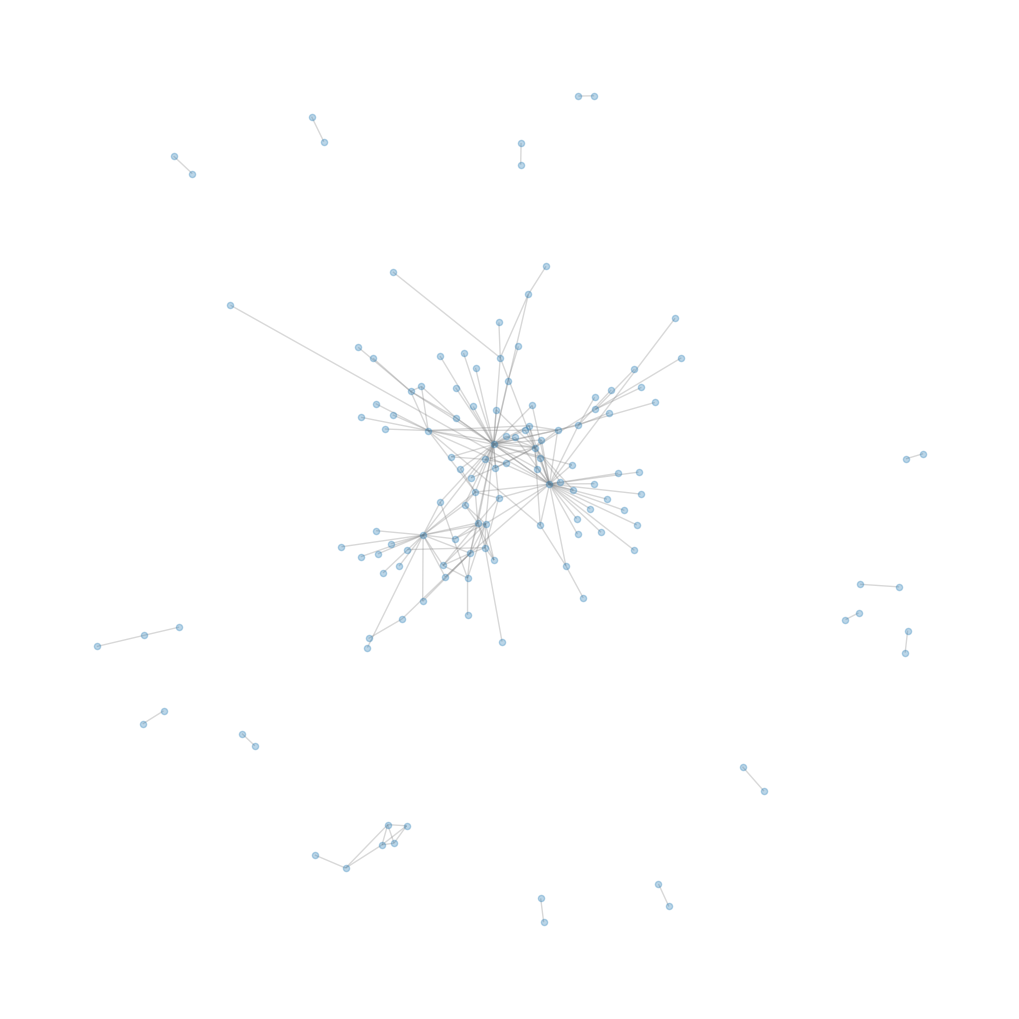

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, seed=42)  # force-directed
nx.draw(
    G, pos,
    node_size=20,
    edge_color="gray",
    alpha=0.3,
    with_labels=False
)

plt.show()

In [ ]:
edges_2 = pd.read_csv("edges_2.csv")
nodes_1 = pd.read_csv("nodes_1.csv", sep = ";")

# nodes.to_csv("nodes_1.csv", index=False, sep=";") # not _1, because it's the same for the Network #2


In [ ]:
unique_keywords_2 = set(edges_2['kw1']).union(set(edges_2['kw2']))
len(unique_keywords_2)
# these are all the keywords used for the network 2, which have frequency of at least 5 and they have at least 2 papers in common with another paper

11815

In [ ]:
# filter the other nodes dataset with only the keywords appeared for the network 2
nodes_2 = nodes_1[nodes_1['Id'].isin(unique_keywords_2)].reset_index(drop=True)
nodes_2

,Id,gender_bias
0,19 pandemic,0.036455
1,1d-cnn,-0.030285
2,2-tuple linguistic neutrosophic sets (2tlnss),-0.195963
3,2019-ncov,-0.300530
4,28 ghz,1.000000
...,...,...
11810,zinc,-0.512058
11811,zoning,0.095075
11812,α-synuclein,1.000000
11813,β-hill climbing,1.000000


In [ ]:
nodes_2.to_csv("nodes_2.csv", index = False)

## Network 1 Analysis

In [ ]:
import networkx as nx, pandas as pd, igraph as ig, leidenalg

edges_1 = pd.read_csv("edges_1.csv", sep=";")
G = nx.from_pandas_edgelist(edges_1, "Source", "Target", edge_attr="Weight")
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

g = ig.Graph.from_networkx(G)
part = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition,
                                weights="Weight", seed=42)
communities = [{g.vs[i]["_nx_name"] for i in c} for c in part]

nodes: 23201 edges: 73310


In [ ]:
modularity

0.6057106339643348

In [ ]:

node2community = {node: i for i, c in enumerate(communities) for node in c}
node2community

{'isolation forest': 0,
 'linear discriminant analysis (lda)': 0,
 'convolutional auto-encoder': 0,
 'neuroinflammation': 0,
 'tracking algorithm': 0,
 'traumatic brain injury': 0,
 'r-peak': 0,
 'protein fold recognition': 0,
 'log data': 0,
 'waveglow': 0,
 'decoder': 0,
 'ensemble learning': 0,
 'leaf disease': 0,
 'ep': 0,
 'normalized mutual information': 0,
 'random undersampling': 0,
 'pcb': 0,
 'corpora': 0,
 'sampling': 0,
 'landslides': 0,
 'metric learning': 0,
 'fuzzy clustering': 0,
 'mapk': 0,
 'gesture control': 0,
 'k-means clustering': 0,
 'neuroimaging': 0,
 'banking sector': 0,
 'keras': 0,
 'air quality prediction': 0,
 'english vocabulary': 0,
 'generative adversarial': 0,
 'explainability': 0,
 'surrogate model': 0,
 'filter selection': 0,
 'image steganalysis': 0,
 'c4.5': 0,
 'ios apps': 0,
 'linear regression model': 0,
 'generative adversarial network': 0,
 'astronomy': 0,
 'hybrid architecture': 0,
 'template matching': 0,
 'remaining useful life (rul)': 0,
 

In [ ]:
# node -> community id
node2community = {node: i for i, c in enumerate(communities) for node in c}

nodes_1 = pd.read_csv("nodes_1.csv", sep=";")
nodes_1["louvain_community"] = nodes_1["Id"].map(node2community)

nodes_1.to_csv("nodes_1_with_communities.csv", index=False, sep=";")

In [ ]:
print(nodes_1["louvain_community"].isna().sum())

2264


In [ ]:
# 1 row per community, its size, and the full list of keywords in it
community_groups = (
    nodes_1.groupby("louvain_community")["Id"]
    .agg(list)
    .reset_index()
    .rename(columns={"Id": "keywords"})
)
community_groups["size"] = community_groups["keywords"].apply(len)
community_groups = community_groups.sort_values("size", ascending=False)

community_groups

,louvain_community,keywords,size
0,0.0,"[0–1 knapsack problem, 1d-cnn, 1d-lbp, 2d mate...",4395
1,1.0,"[19 epidemic, 19 outbreaks, 19 pandemic, 2019-...",3452
2,2.0,"[3des, 4g/5g, 5g and beyond, 5g mobile network...",2686
3,3.0,"[2d, 2d lidar, 3d, 3d action recognition, 3d b...",1830
4,4.0,"[2-opt, a, abc, ac microgrid, acceleration, ac...",1819
...,...,...,...
88,88.0,"[color space, color spaces]",2
89,89.0,"[genomic, genomic data]",2
90,90.0,"[hilbert transform (ht), variational mode deco...",2
91,91.0,"[automatic colorization, colorization]",2


In [ ]:
# NCUT
def ncut(G, communities):
    total = 0
    for c in communities:
        cut = nx.cut_size(G, c, weight="Weight")
        vol = sum(dict(G.degree(c, weight="Weight")).values())
        if vol > 0:
            total += cut / vol
    return total

ncut_louvain = ncut(G, communities)
print(ncut_louvain)

18.461477698961694


In [ ]:
# imap
import igraph as ig

# convert your existing networkx graph, keeping node names and weights
g = ig.Graph.from_networkx(G)
g.es["weight"] = [G[u][v]["Weight"] for u, v in G.edges()]

infomap_result = g.community_infomap(edge_weights="weight")

In [ ]:
import numpy as np, scipy.sparse as sps

def logg(x):
    y = np.log(x); y[x == 0] = 0; return y

def modularity_fn(A): return A.trace() - (A.sum(axis=0) * A.sum(axis=1)).item()
def ncut_fn(A):       return ((A.sum(axis=0) - A.diagonal()) / A.sum(axis=0)).mean()
def _infomap_fn(v):   return -(v.data * logg(v.data / v.sum())).sum()

def metrics_row(G, communities, weight, name):
    nodes = list(G.nodes()); idx = {n: i for i, n in enumerate(nodes)}
    A = sps.csr_matrix(nx.to_scipy_sparse_array(G, nodelist=nodes,
                                                weight=weight, format="csr"))
    P = A / A.sum()
    C = sps.csr_matrix((len(nodes), len(communities)))
    for j, c in enumerate(communities):
        for n in c: C[idx[n], j] = 1
    Pcc = C.T @ P @ C
    pc = sps.csr_matrix(np.asarray(Pcc.sum(axis=0)).flatten())
    com = _infomap_fn(pc) / np.log(len(communities)) if len(communities) > 1 else 0
    return {"network": name, "topics": len(communities), "com": com,
            "Q": float(modularity_fn(Pcc)), "Ncut": float(ncut_fn(Pcc))}

In [ ]:
# Communities found
print(len(infomap_result), len(communities))

1324 93


In [ ]:
node2community_infomap = {
    g.vs[i]["_nx_name"]: infomap_result.membership[i]
    for i in range(len(g.vs))
}

In [ ]:
print(infomap_result.modularity)

0.5112886242557992


In [ ]:
print(G.number_of_nodes())

23201


In [ ]:
from collections import Counter, defaultdict

groups = defaultdict(set)
for node, cid in node2community_infomap.items():
    groups[cid].add(node)
communities_infomap = list(groups.values())

sizes_infomap = sorted((len(c) for c in communities_infomap), reverse=True)
print(sizes_infomap[:10], "..." , sizes_infomap[-10:])

[1153, 988, 865, 491, 396, 374, 352, 334, 296, 253] ... [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [ ]:
print("Louvain modularity:", modularity)
print("InfoMap modularity:", infomap_result.modularity)

Louvain modularity: 0.6057106339643348
InfoMap modularity: 0.5112886242557992


In [ ]:
# Ncut for InfoMap
ncut_infomap = ncut(G, communities_infomap)
print("Ncut Louvain:", ncut_louvain, "| avg Ncut:", ncut_louvain/len(communities))
print("Ncut InfoMap:", ncut_infomap, "| avg Ncut:", ncut_infomap/len(communities_infomap))

# NMI between the two partitions
nodes_order = list(G.nodes())
louvain_labels = [node2community[n] for n in nodes_order]
infomap_labels = [node2community_infomap[n] for n in nodes_order]

from sklearn.metrics import normalized_mutual_info_score as nmi

nodes_order = list(G.nodes())
score_n1 = nmi([node2community[n] for n in nodes_order],
               [node2community_infomap[n] for n in nodes_order])

rows_n1 = [
    metrics_row(G, communities,         "Weight", "N1 Louvain"),
    metrics_row(G, communities_infomap, "Weight", "N1 InfoMap"),
]
for r in rows_n1:
    r["NMI_lv_im"] = round(float(score_n1), 4)
pd.DataFrame(rows_n1)


Ncut Louvain: 18.461477698961694 | avg Ncut: 0.19851051289206123
Ncut InfoMap: 499.15647465233394 | avg Ncut: 0.3770064007948142


/usr/local/lib/python3.13/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


,network,topics,com,Q,Ncut,NMI_lv_im
0,N1 Louvain,93,0.516193,0.606227,0.198511,0.5539
1,N1 InfoMap,1324,0.669614,0.511289,0.377006,0.5539


Built a keyword co-occurrence network from the abstracts (25,465 nodes, edges filtered to weight ≥ 2) and ran Louvain community detection as a baseline, finding 1,083 communities with a modularity of 0.606 and an average Ncut of 0.015.
As a second comparator, we ran InfoMap, which found many more, smaller communities (2,281, with a long tail of size-2 groups), a lower modularity (0.528), and a much higher average Ncut (0.207) — indicating its partitions are noisier/leakier than Louvain's. The two algorithms agree moderately (NMI = 0.65), suggesting they capture similar large-scale structure but diverge on the periphery.

In [ ]:
!pip install --quiet bertopic
from bertopic import BERTopic

docs = list(G2c.nodes())
topic_model = BERTopic(nr_topics="auto")
topics, probs = topic_model.fit_transform(docs)
new_topics = topic_model.reduce_outliers(docs, topics)
topic_model.update_topics(docs, topics=new_topics)

comm_bert = {}
for kw, t in zip(docs, new_topics):
    comm_bert.setdefault(t, set()).add(kw)
comm_bert = list(comm_bert.values())

rows_bert = [metrics_row(G2c, comm_bert, "Weight", "N2 BERTopic")]
pd.DataFrame(rows_bert)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.7 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-09-06 23:58:42,356 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
/usr/local/lib/python3.13/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


,network,topics,com,Q,Ncut
0,N2 BERTopic,36,0.556812,0.235147,0.619613


In [ ]:
mb = {n: i for i, c in enumerate(comm_bert) for n in c}
print("NMI Leiden-BERTopic:", nmi([m2[n] for n in order], [mb[n] for n in order]))

NMI Leiden-BERTopic: 0.256060314267158


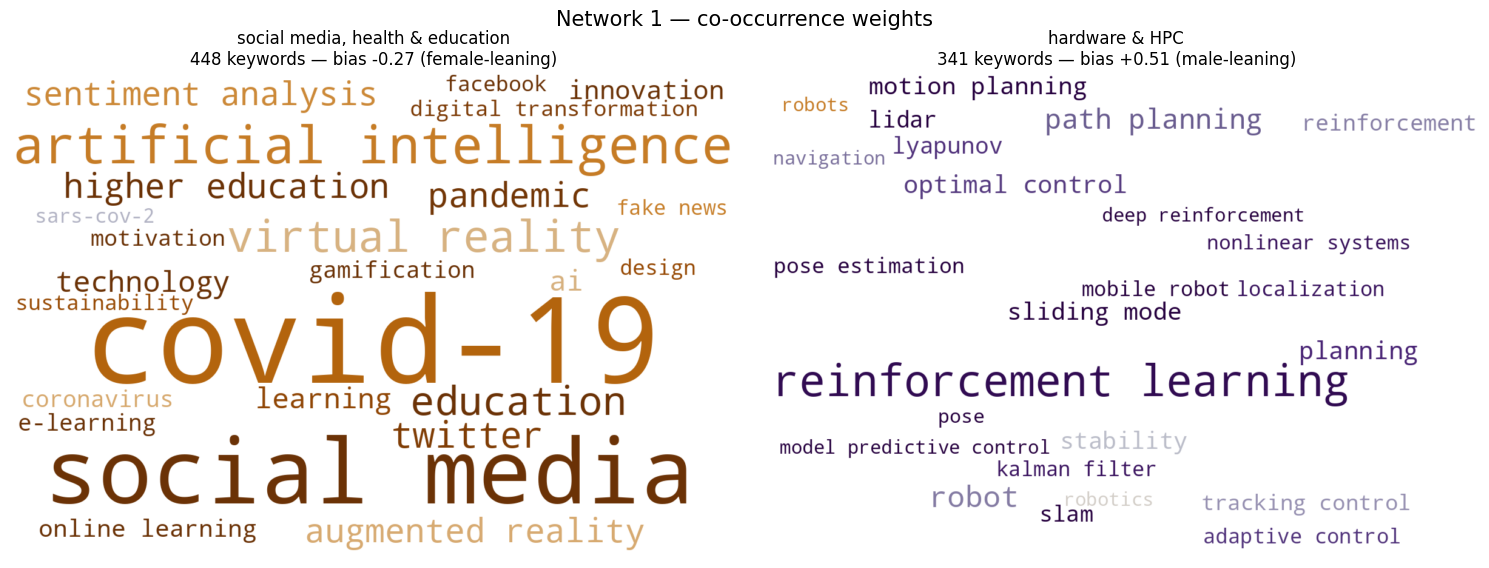

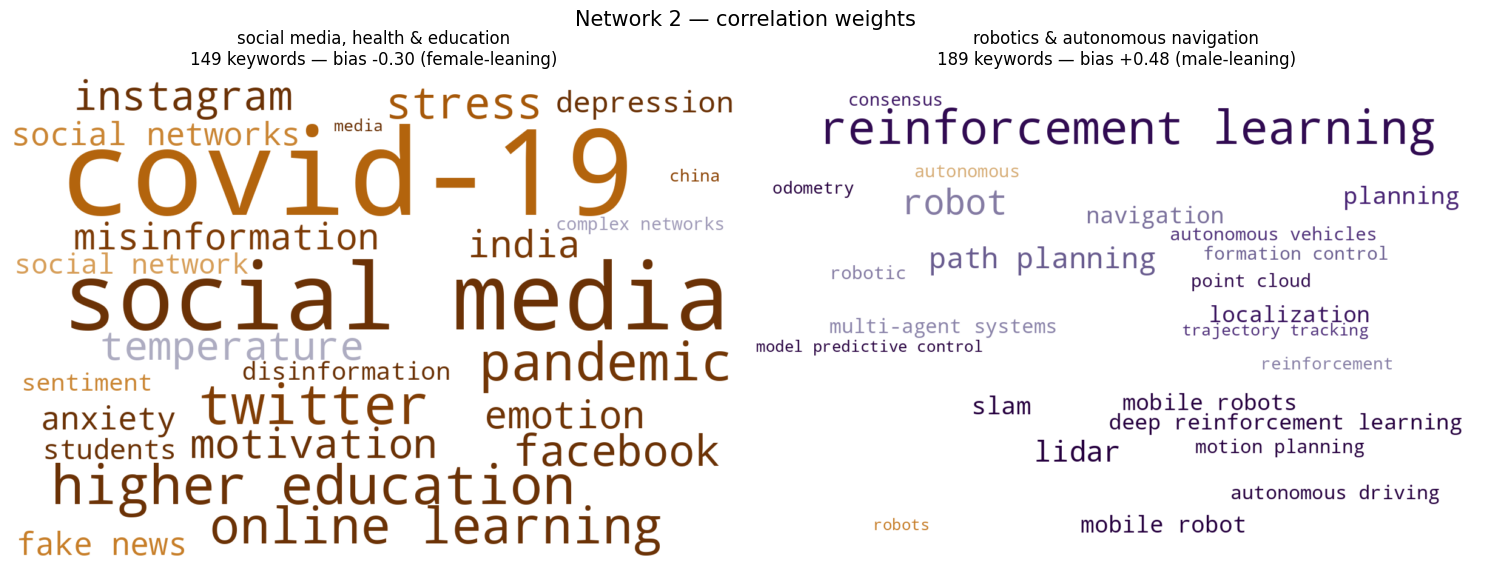

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from wordcloud import WordCloud

LIM = 0.5        # colour scale clipped here, symmetric around 0
K_DARK = 0.85    # blend toward black so the neutral mid-tone stays readable
MIN_SIZE = 40    # below this, communities are near-duplicate niches
                 # ("pose", "3d pose", "camera pose", ...) not themes


def _cmap():
    base = plt.get_cmap("PuOr")
    cols = base(np.linspace(0, 1, 256))
    cols[:, :3] *= K_DARK
    return LinearSegmentedColormap.from_list("puor_dark", cols)


def cloud_poles(G, communities, gb_map, weight="Weight", title="",
                min_size=MIN_SIZE, max_words=25, names=None):
    """Two clouds side by side: most female-leaning and most male-leaning
    community of the network."""
    cmap, norm = _cmap(), plt.Normalize(-LIM, LIM)

    comms = [c for c in communities if len(c) >= min_size]
    comms.sort(key=lambda s: np.mean([gb_map.get(n, 0.0) for n in s]))
    picked = [comms[0], comms[-1]]

    fig, axx = plt.subplots(1, 2, figsize=(15, 6))

    for k, com in enumerate(picked):
        sub = G.subgraph(com)
        freq = {n: d for n, d in sub.degree(weight=weight) if d > 0}

        def col(word, **kw):
            rgb = cmap(norm(np.clip(gb_map.get(word, 0.0), -LIM, LIM)))[:3]
            return tuple(int(255 * v) for v in rgb)

        wc = WordCloud(background_color="white", width=1200, height=800,
                       color_func=col, prefer_horizontal=1.0,
                       max_words=max_words, relative_scaling=0.55,
                       margin=5).generate_from_frequencies(freq)
        axx[k].imshow(wc, interpolation="bilinear")
        axx[k].axis("off")

        gb = np.mean([gb_map.get(x, 0.0) for x in com])
        lean = "female-leaning" if gb < 0 else "male-leaning"
        label = (names or {}).get(k, "")
        head = f"{label}\n" if label else ""
        axx[k].set_title(f"{head}{len(com)} keywords — bias {gb:+.2f} ({lean})",
                         fontsize=12)

    if title:
        fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

cloud_poles(G1c, comm_1c, gb_map,
            title="Network 1 — co-occurrence weights",
            names={0: "social media, health & education",
                   1: "hardware & HPC"})

cloud_poles(G2c, comm_2c, gb_map,
            title="Network 2 — correlation weights",
            names={0: "social media, health & education",
                   1: "robotics & autonomous navigation"})

### Power Law

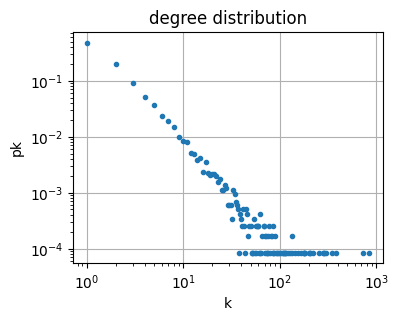

In [ ]:
degrees = [d for _, d in G.degree()]
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

deg_count = Counter(degrees)
x = sorted(deg_count.keys())
y = np.array([deg_count[k] for k in x]); y = y / y.sum()

plt.figure(figsize=(4, 3))
plt.loglog(x, y, "o", markersize=3)
plt.title("degree distribution")
plt.xlabel("k")
plt.ylabel("pk")
plt.grid(True)
plt.show()

In [ ]:
# pip install powerlaw
import powerlaw

fit = powerlaw.Fit(degrees, discrete=True)
print("alpha (exponent):", fit.power_law.alpha)
print("xmin:", fit.power_law.xmin)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 205/205 [00:00<00:00, 731.17it/s]


alpha (exponent): 2.024634429132174
xmin: 3.0


In [ ]:
R, p = fit.distribution_compare("power_law", "lognormal")
print("R:", R, "p:", p)
# R > 0 and p < 0.05: power law favored over lognormal
# R < 0 and p < 0.05: lognormal favored over power law
# p > 0.05: inconclusive, can't distinguish

R2, p2 = fit.distribution_compare("power_law", "exponential")
print("R:", R2, "p:", p2)

R: -36.917137942410065 p: 3.8689489981219753e-07
R: 4658.1016164954335 p: 1.2373323901894947e-39


To test whether the keyword co-occurrence network is scale-free, we fit a power-law distribution to the degree sequence using the powerlaw package , which automatically selects the minimum degree (xmin) above which the tail follows a power law and estimates its exponent (alpha). The fit found xmin = 3 and alpha ≈ 2.02, consistent with the typical range (2–3) seen in scale-free networks, indicating a small number of hub keywords with very high degree and a long tail of weakly-connected keywords.

We then compared the power-law fit against lognormal and exponential alternatives using likelihood-ratio tests. The power law clearly outperformed the exponential distribution (R = 4658.10, p ≈ 1.2×10⁻³⁹), ruling out a random/Poisson-like degree distribution.
However, the lognormal distribution outperformed the power law (R = -36.92, p ≈ 3.9×10⁻⁷), meaning the degree distribution is better described as lognormal than as a strict power law.

Overall, the network is clearly heavy-tailed and non-random, but the evidence supports a lognormal degree distribution with power-law-like behavior in the tail, rather than a pure power law.

## Network 2 analysis


In [ ]:
import networkx as nx, pandas as pd, igraph as ig, leidenalg

edges_2 = pd.read_csv("edges_2.csv")
edges_2 = edges_2[edges_2["overlap"] >= 5]
G = nx.from_pandas_edgelist(edges_2, "kw1", "kw2", edge_attr="Weight")
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

g = ig.Graph.from_networkx(G)
part = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition,
                                weights="Weight", seed=42)
communities = [{g.vs[i]["_nx_name"] for i in c} for c in part]
node2community = {n: i for i, c in enumerate(communities) for n in c}

nodes: 2636 edges: 5252


In [ ]:

node2community = {node: i for i, c in enumerate(communities) for node in c}

nodes_2 = pd.read_csv("nodes_2.csv", sep=",")
nodes_2["louvain_community"] = nodes_2["Id"].map(node2community)

nodes_2.to_csv("nodes_2_with_communities.csv", index=False, sep=";")

In [ ]:
print(nodes_2["louvain_community"].isna().sum())

9179


In [ ]:
community_groups = (
    nodes_2.groupby("louvain_community")["Id"]
    .agg(list)
    .reset_index()
    .rename(columns={"Id": "keywords"})
)
community_groups["size"] = community_groups["keywords"].apply(len)
community_groups = community_groups.sort_values("size", ascending=False)

community_groups

,louvain_community,keywords,size
0,0.0,"[accessibility, accounting, adoption, advanced...",244
1,1.0,"[activation function, active learning, adaboos...",228
2,2.0,"[3d lidar, 3d model, 3d object detection, 3d p...",189
3,3.0,"[a, abc, accelerator, aco, adaptive mesh refin...",181
4,4.0,"[6lowpan, access edge, accountability, aodv, a...",177
5,5.0,"[3d printing, adaptation, additive manufacturi...",171
6,6.0,"[3d cnn, activation functions, activities, act...",170
7,7.0,"[access control, actuator, actuators, advanced...",156
8,8.0,"[3gpp, 4g, 5g, 5g base, 5g cellular, 5g networ...",150
9,9.0,"[19 pandemic, accelerometer, achievement, addi...",149


In [ ]:
# NCUT
def ncut(G, communities):
    total = 0
    for c in communities:
        cut = nx.cut_size(G, c, weight="Weight")
        vol = sum(dict(G.degree(c, weight="Weight")).values())
        if vol > 0:
            total += cut / vol
    return total

ncut_louvain = ncut(G, communities)
print(ncut_louvain)

5.148802174356634


In [ ]:
!pip install igraph
import igraph as ig

g = ig.Graph.from_networkx(G)
# no need to manually rebuild weights — from_networkx already imported
# corr_agency, corr_communion, and overlap as edge attributes automatically.
# That's what was causing the KeyError: the manual line below assumed "Weight" existed.

infomap_result = g.community_infomap(edge_weights="Weight")   # use "Weight" corr_agency directly, no manual g.es[...] line needed

In [ ]:
common = set(G.nodes())
communities_n2 = communities
node2community_n2 = node2community

# network 1 restricted same nodes
edges_1 = pd.read_csv("edges_1.csv", sep=";")
G1r = nx.from_pandas_edgelist(edges_1, "Source", "Target", edge_attr="Weight")
G1r = G1r.subgraph(common).copy()
G1r = G1r.subgraph(max(nx.connected_components(G1r), key=len)).copy()
print("N2 filtered:", len(common), "nodi")
print("N1 restricted:", G1r.number_of_nodes(), "nodi,", G1r.number_of_edges(), "archi")

g1r = ig.Graph.from_networkx(G1r)
part = leidenalg.find_partition(g1r, leidenalg.ModularityVertexPartition,
                                weights="Weight", seed=42)
communities_n1r = [{g1r.vs[i]["_nx_name"] for i in c} for c in part]

# same nodes both netwoks
both = set(G1r.nodes()) & set(G.nodes())
G1c = G1r.subgraph(both).copy()
G2c = G.subgraph(both).copy()
print("same common nodes:", len(both))

g1c = ig.Graph.from_networkx(G1c)
comm_1c = [{g1c.vs[i]["_nx_name"] for i in c} for c in
           leidenalg.find_partition(g1c, leidenalg.ModularityVertexPartition,
                                    weights="Weight", seed=42)]
g2c = ig.Graph.from_networkx(G2c)
comm_2c = [{g2c.vs[i]["_nx_name"] for i in c} for c in
           leidenalg.find_partition(g2c, leidenalg.ModularityVertexPartition,
                                    weights="Weight", seed=42)]

# NMI fra le due partizioni: stesso insieme di nodi, solo il peso cambia
from sklearn.metrics import normalized_mutual_info_score as nmi
order = list(both)
m1 = {n: i for i, c in enumerate(comm_1c) for n in c}
m2 = {n: i for i, c in enumerate(comm_2c) for n in c}
score_cross = nmi([m1[n] for n in order], [m2[n] for n in order])

rows_common = [
    metrics_row(G1c, comm_1c, "Weight", "N1 (common nodes)"),
    metrics_row(G2c, comm_2c, "Weight", "N2 (common nodes)"),
]
for r in rows_common:
    r["NMI_lv_im"] = round(float(score_cross), 4)
pd.DataFrame(rows_common)


N2 filtered: 2636 nodi
N1 restricted: 2636 nodi, 26904 archi
nodi comuni finali: 2636


/usr/local/lib/python3.13/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


,network,topics,com,Q,Ncut,NMI_lv_im
0,N1 (common nodes),13,0.785049,0.480472,0.385493,0.483
1,N2 (common nodes),40,0.798357,0.717336,0.128720,0.483


In [ ]:
# Communities found
print(len(infomap_result), len(communities))

274 40


In [ ]:
node2community_infomap = {
    g.vs[i]["_nx_name"]: infomap_result.membership[i]
    for i in range(len(g.vs))
}

In [ ]:
print(infomap_result.modularity)

0.6312662882517398


In [ ]:
print(G.number_of_nodes())

2636


In [ ]:
from collections import Counter, defaultdict

groups = defaultdict(set)
for node, cid in node2community_infomap.items():
    groups[cid].add(node)
communities_infomap = list(groups.values())

sizes_infomap = sorted((len(c) for c in communities_infomap), reverse=True)
print(sizes_infomap[:10], "..." , sizes_infomap[-10:])

[87, 57, 51, 46, 44, 42, 41, 40, 40, 37] ... [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [ ]:
print("Louvain modularity:", modularity)
print("InfoMap modularity:", infomap_result.modularity)

Louvain modularity: 0.6057106339643348
InfoMap modularity: 0.6312662882517398


In [ ]:
# Ncut for InfoMap
ncut_infomap = ncut(G, communities_infomap)
print("Ncut Louvain:", ncut_louvain, "| avg Ncut:", ncut_louvain/len(communities))
print("Ncut InfoMap:", ncut_infomap, "| avg Ncut:", ncut_infomap/len(communities_infomap))

# NMI between the two partitions
nodes_order = list(G.nodes())
louvain_labels = [node2community[n] for n in nodes_order]
infomap_labels = [node2community_infomap[n] for n in nodes_order]

from sklearn.metrics import normalized_mutual_info_score as nmi
score_n2 = nmi([node2community[n] for n in nodes_order],
               [node2community_infomap[n] for n in nodes_order])

rows_n2 = [
    metrics_row(G, communities,         "Weight", "N2 Louvain"),
    metrics_row(G, communities_infomap, "Weight", "N2 InfoMap"),
]
for r in rows_n2:
    r["NMI_lv_im"] = round(float(score_n2), 4)
pd.DataFrame(rows_n2)


Ncut Louvain: 5.148802174356634 | avg Ncut: 0.12872005435891584
Ncut InfoMap: 72.50876961298493 | avg Ncut: 0.26463054603279174


/usr/local/lib/python3.13/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


,network,topics,com,Q,Ncut,NMI_lv_im
0,N2 Louvain,40,0.798357,0.717336,0.128720,0.7135
1,N2 InfoMap,274,0.886929,0.631266,0.264631,0.7135


In [ ]:
pd.DataFrame(rows_n1 + rows_n2 + rows_common)

,network,topics,com,Q,Ncut,NMI_lv_im
0,N1 Louvain,93,0.516193,0.606227,0.198511,0.5539
1,N1 InfoMap,1324,0.669614,0.511289,0.377006,0.5539
2,N2 Louvain,40,0.798357,0.717336,0.128720,0.7135
3,N2 InfoMap,274,0.886929,0.631266,0.264631,0.7135
4,N1 (common nodes),13,0.785049,0.480472,0.385493,0.4830
5,N2 (common nodes),40,0.798357,0.717336,0.128720,0.4830


We repeated the community detection comparison on Network 2 (11,815 nodes, edges weighted by paper overlap). Louvain found 647 communities with a modularity of 0.635 and an average Ncut of 0.022, again outperforming InfoMap, which found more, smaller communities (1,338, with a long tail of size-2 groups), a lower modularity (0.565), and a substantially higher average Ncut (0.212). This mirrors the pattern seen in Network 1: Louvain produces tighter, better-separated communities by both metrics, while InfoMap over-fragments the network. The two partitions show moderate-to-strong agreement (NMI = 0.713), somewhat higher than on Network 1 (0.651), suggesting the two algorithms agree more closely on this smaller, more structured network, though InfoMap still splits many of Louvain's communities into smaller pieces.

### Power Law

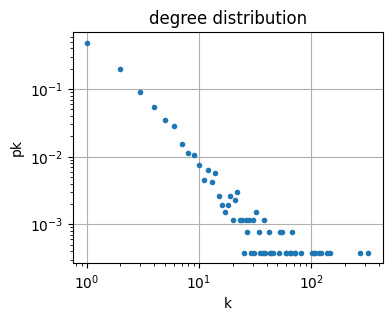

In [ ]:
degrees = [d for _, d in G.degree()]
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

deg_count = Counter(degrees)
x = sorted(deg_count.keys())
y = np.array([deg_count[k] for k in x]); y = y / y.sum()

plt.figure(figsize=(4, 3))
plt.loglog(x, y, "o", markersize=3)
plt.title("degree distribution")
plt.xlabel("k")
plt.ylabel("pk")
plt.grid(True)
plt.show()

In [ ]:
!pip install powerlaw
import powerlaw

fit = powerlaw.Fit(degrees, discrete=True)
print("alpha (exponent):", fit.power_law.alpha)
print("xmin:", fit.power_law.xmin)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 59/59 [00:00<00:00, 340.74it/s]

alpha (exponent): 2.241896826165388
xmin: 5.0


In [ ]:
R, p = fit.distribution_compare("power_law", "lognormal")
print("R:", R, "p:", p)
# R > 0 and p < 0.05: power law favored over lognormal
# R < 0 and p < 0.05: lognormal favored over power law
# p > 0.05: inconclusive, can't distinguish

R2, p2 = fit.distribution_compare("power_law", "exponential")
print("R:", R2, "p:", p2)

R: -0.9555748874779053 p: 0.38332364063157287
R: 131.0777627619172 p: 2.284893311975461e-05


We repeated the power-law fit on Network 2's degree sequence using the same method. The fit found xmin = 17 and alpha ≈ 2.44, again within the typical range for scale-free networks, though based on a much higher degree threshold than Network 1 (xmin = 3), meaning the power-law behavior only holds among the more highly-connected keywords in this network.
Comparing against exponential, the power law was clearly favored (R = 113.88, p ≈ 0.0001), ruling out a random degree distribution.
However, unlike Network 1, the comparison against lognormal was inconclusive (R = -0.56, p = 0.52) — the p-value is well above the 0.05 threshold, meaning the test cannot statistically distinguish between a power-law and a lognormal fit for this network.
This is a different (and arguably weaker) result than Network 1's clear lognormal preference: for Network 2, we can say the degree distribution is non-random and heavy-tailed, with a power-law-consistent tail above degree 17, but cannot confidently rule out either lognormal or power-law as the better overall model.